# 1.Perkenalan

### Nama  : Muhammad Izzat
### Batch : HCK-041
### Dataset yang digunakan adalah dataset yang menjelaskan tentang rekam medis dari pasien sebuah rumah sakit/klinik
### Latar bealakang ; Stroke adalah salah satu penyebab kematian terbesar di indonesia. deteksi dini sangat penting agar pasien yang berisiko bisa mendapat penanganan lebi cepet. project ini membangun model klasifikasi untuk memprediksi apakah seseorang berisiko terkena stroke 
### Objective membuat model machine learning dengan 5 algoritma berbeda (KNN,SVM,Decision tree,Random Forest, dan Boosting)

# 2.Import Libraries

In [1]:
# Semua library yang digunakan dalam project ini
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
import warnings
warnings.filterwarnings('ignore')
import joblib

# 3.Data Loading

In [2]:
df = pd.read_csv('stroke_data.csv')
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [3]:
# cek 10 data pertama dan terakhir
df.head(10)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [4]:
df.tail(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5100,68398,Male,82.0,1,0,Yes,Self-employed,Rural,71.97,28.3,never smoked,0
5101,36901,Female,45.0,0,0,Yes,Private,Urban,97.95,24.5,Unknown,0
5102,45010,Female,57.0,0,0,Yes,Private,Rural,77.93,21.7,never smoked,0
5103,22127,Female,18.0,0,0,No,Private,Urban,82.85,46.9,Unknown,0
5104,14180,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown,0
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [5]:
# cek ukuran data
df.shape

(5110, 12)

In [6]:
# menghapus kolom id karena tidak informatif untuk target
df = df.drop(columns=["id"])

In [7]:
# cek info yang ada pada dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


ada 1 kolom yang datanya bolong

In [8]:
# cek nilai unik masing2 kolom
df.nunique()

gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64

kolom gender berisi 3 nilai unik, secara logis seharusnya hanya ada 2 nilai unik yaitu male dan female

In [9]:
#cek value dari kolom gender
df['gender'].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

hanya ada satu baris value other pada kolom gender, keputusannya akan di drop karena bisa menyebabkan error ketika splitting data dengan stratify

In [10]:
# hapus baris other pada kolom gender
df = df[df["gender"] != "Other"]

In [11]:
# cek ukuran data setelah baris other dihapus
df.shape

(5109, 11)

In [12]:
#cek data yang duplikat
df.duplicated().sum()

0

tidak ada data yang duplikat

In [13]:
# rename kolom 'Residence_type' menjadi huruf kecil semua dan bmi jadi body_mass
df = df.rename(columns={'Residence_type': 'residence_type', 'bmi': 'body_mass'})

In [14]:
# cek kembali nama kolom yang udah di rename
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'residence_type', 'avg_glucose_level', 'body_mass',
       'smoking_status', 'stroke'],
      dtype='object')

# 4.EDA

In [15]:
# cek angka statistik dari dataset
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,body_mass,stroke
count,5109.000000,5109.000000,5109.000000,5109.000000,4908.00000,5109.000000
mean,43.229986,0.097475,0.054022,106.140399,28.89456,0.048738
std,22.613575,0.296633,0.226084,45.285004,7.85432,0.215340
min,0.080000,0.000000,0.000000,55.120000,10.30000,0.000000
25%,25.000000,0.000000,0.000000,77.240000,23.50000,0.000000
50%,45.000000,0.000000,0.000000,91.880000,28.10000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.10000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.60000,1.000000


### distribusi data

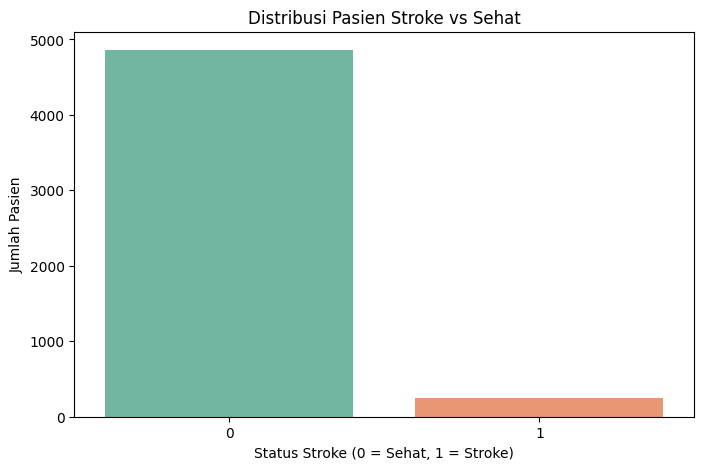

In [16]:
# cek distribusi data
plt.figure(figsize=(8,5))
sns.countplot(x='stroke', data=df, palette='Set2')
plt.title('Distribusi Pasien Stroke vs Sehat')
plt.xlabel('Status Stroke (0 = Sehat, 1 = Stroke)')
plt.ylabel('Jumlah Pasien')
plt.show()

dari grafik di atas diketahui bahwa jumlah pasien sehat(0) lebih mendominasi jauh ketimbang jumlah pasien yang terkena stroke(1), dapat diketahui juga dari rata2 statistik pada kolom stroke bernilai 0,048 atau 4,8%. ini menunjukkan bahwa dataset yang kita gunakan mengalami ketidak seimbangan distribusi data 

### korelasi antar fitur numerik

In [17]:
# cek korelasi fitur numerik pada target
corr = df[['age', 'avg_glucose_level', 'body_mass', 'stroke']].corr()
corr

,age,avg_glucose_level,body_mass,stroke
age,1.000000,0.238323,0.333314,0.245239
avg_glucose_level,0.238323,1.000000,0.175672,0.131991
body_mass,0.333314,0.175672,1.000000,0.042341
stroke,0.245239,0.131991,0.042341,1.000000


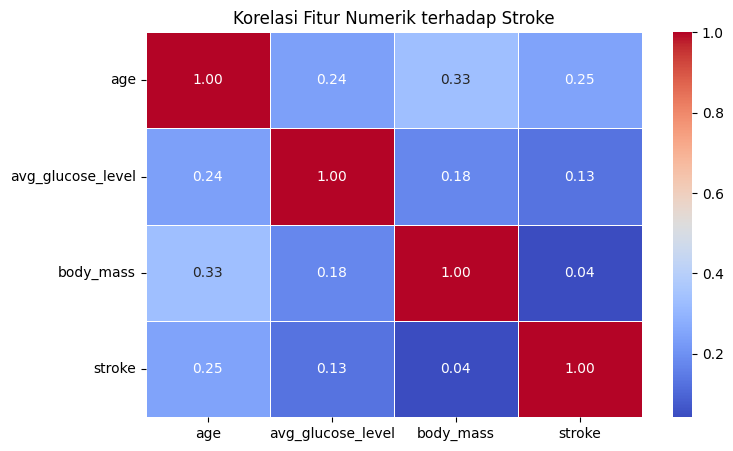

In [18]:
# plotting heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df[['age', 'avg_glucose_level', 'body_mass', 'stroke']].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelasi Fitur Numerik terhadap Stroke')
plt.show()

dari heatmap ini menunjukkan bahwa korelasi fitur numerik terhadap fitur target yaitu stroke bisa disimpulkan kalau 

-fitur umur mempunyai hubungan positif paling kuat dengan stroke dibandingkan fitur yang lain, dengan nilai korelasi yang tinggi sebesar 0.25 artinya semakin bertambahnya umur semakin besar juga peluang seseorang terkena stroke

-fitur gula darah punya hubungan positif tapi lemah dengan nilai korelasi di angka 0.13, artinya seseorang dengan tingkat gula darah itu punya potensi terkena stroke juga

-adapun fitur terakhir dengan korelasi terkecil adalah body mass, fitur ini secara linear hampir tidak punya hubungan dengan resiko stroke  

### korelasi age vs stroke

Text(0, 0.5, 'Jumlah Pasien')

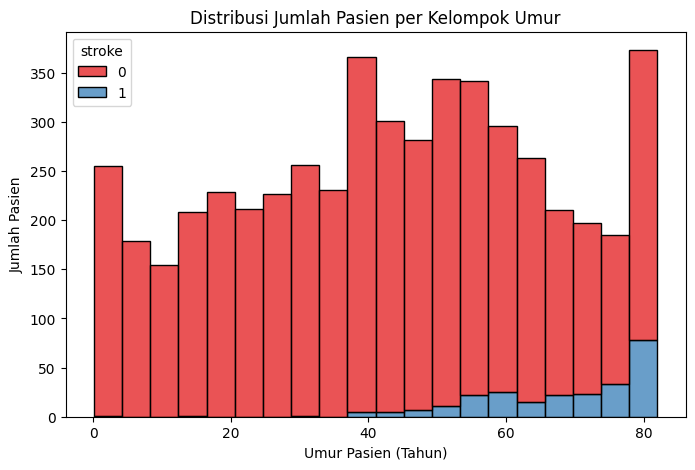

In [19]:
# membuat plot histogram untuk kelompok umur 
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(ax=ax, data=df, x='age', hue='stroke', multiple='stack', palette='Set1', bins=20)
ax.set_title('Distribusi Jumlah Pasien per Kelompok Umur')
ax.set_xlabel('Umur Pasien (Tahun)')
ax.set_ylabel('Jumlah Pasien')


berdasarkan heatmap diatas, hubungan kedua ini punya korelasi yang paling tinggi dibanding yang lain, jadi semakin naik umur seseorang semakin punya resiko terkena stroke, dari plot histogram multiple stack ini bisa diketahui kalau resiko stroke itu meningkat secara non-linear pada rentang umur 40-80 tahun, artinya di rentang inilah seseorang itu beresiko terkena stroke secara drastis

### korelasi body mass vs stroke

Text(0, 0.5, 'Jumlah Pasien')

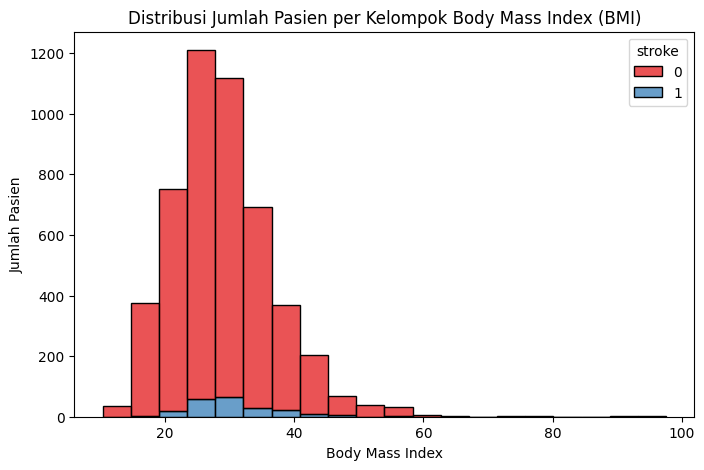

In [20]:
# membuat plot histogram untuk kelompok umur 
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(ax=ax, data=df, x='body_mass', hue='stroke', multiple='stack', palette='Set1', bins=20)
ax.set_title('Distribusi Jumlah Pasien per Kelompok Body Mass Index (BMI)')
ax.set_xlabel('Body Mass Index')
ax.set_ylabel('Jumlah Pasien')

heatmap diatas menunjukkan kalau hubungan linear atara fitur body mass dengan stroke merupakan korelasi paling kecil, adapun secara non linear pasien yang mengalami stroke terlihat menumpuk pada rentang nilai BMI 25-35, artinya di rentang inilah seseorang bisa terkena resiko stroke meningkat drastis. 

kalau merujuk ke standar WHO, mayoritas pasien stroke di data ini numpuknya di rentang overweight sama obesitas BMI 25-35 jadi berat badan berlebih punya korelasi yang tinggi buat stroke
https://www.who.int/data/gho/data/themes/topics/topic-details/GHO/body-mass-index

### korelasi fitur kategorik smoking status terhadap stroke

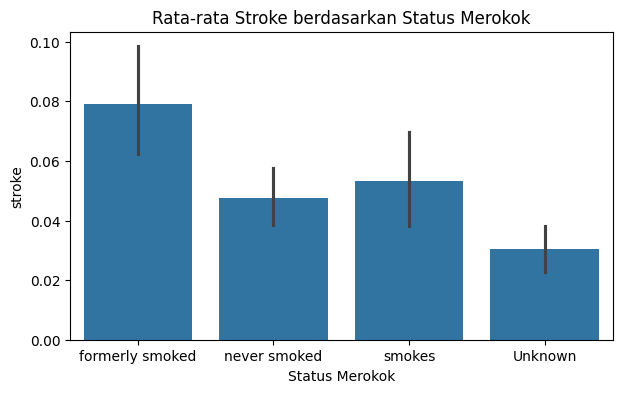

In [21]:
# melihat distribusi status merokok terhadap stroke
plt.figure(figsize=(7,4))
sns.barplot(data=df, x="smoking_status", y="stroke")
plt.title("Rata-rata Stroke berdasarkan Status Merokok")
plt.xlabel("Status Merokok")
plt.show()

dari barplot diatas bisa dilihat kalau pasien dengan status mrokoknya adalah mantan perokok mempunyai nilai tertingggi diantara status yang lain

# 5.Feature Engineering


### mendefinisikan fitur numeric dan categoric

In [22]:
num_cols = ['age', 'avg_glucose_level', 'body_mass']
cat_cols = ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status', 'hypertension', 'heart_disease']

meskipun tipe data pada fitur 'hypertension', dan 'heart_disease' adalah integer, tapi pada hakikatnya tipe data asli mereka adalah kategorikal yang sudah di encode, jadi kita tetap memasukkan mereka ke dalam variable cat_cols

### cek cardinality

In [23]:
cardinality_info = df[cat_cols].nunique()
cardinality_info

gender            2
ever_married      2
work_type         5
residence_type    2
smoking_status    4
hypertension      2
heart_disease     2
dtype: int64

dari hasil cek cardinality semua fitur kategorik termauk ke dalam kategori low cardinality, maka encoding dengan metode onehotencoding adalah metode yang paling cocok

### splitting

In [24]:
# splitting fitur dan target
X = df.drop(columns=['stroke'])
y = df['stroke']

# splitting train test menggunakan rasio 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### handling outlier

In [25]:
# cek distribusi dengan skewness
X_train[['age', 'avg_glucose_level', 'body_mass']].skew()

age                 -0.141719
avg_glucose_level    1.583063
body_mass            1.118202
dtype: float64

dilakukan handling hanya pada 3 kolom numerik tersebut karena kolom numerik sisanya adalah kolom kategorik yang sudah ter encode

-untuk fitur age distribusinya normal, cek menggunakan IQR

-untuk fitur glucose level distribusinya miring kanan/positif skewed, jangan dihandle dengan IQR

-untuk fitur body mass juga distribusing diatas 1 distribusinya miring kanan, jangan dihandle dengan IQR

In [26]:
# cek outlier yang ada pada fitur age
Q1 = X_train['age'].quantile(0.25)
Q3 = X_train['age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#menghitung jumlah outlier yang ada
outliers = X_train[(X_train['age'] < lower_bound) | (X_train['age'] > upper_bound)]

print("hasil outlier yang ditemukan")
print(f"batas bawah: {lower_bound}")
print(f"batas atas : {upper_bound}")
print(f"jumlah outlier yang terdeteksi: {len(outliers)} baris")


hasil outlier yang ditemukan
batas bawah: -29.0
batas atas : 115.0
jumlah outlier yang terdeteksi: 0 baris


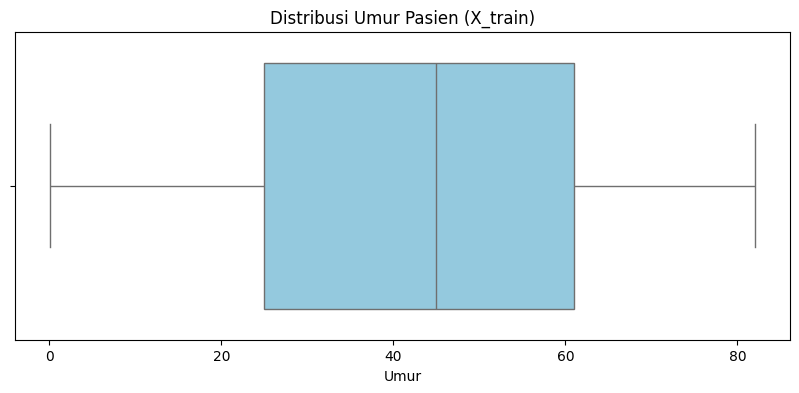

In [27]:
# plotting boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=X_train['age'], color='skyblue')
plt.title("Distribusi Umur Pasien (X_train)")
plt.xlabel("Umur")
plt.show()

kesimpulannya setelah dilakukan cek pada fitur age tidak ditemukan adanya outlier, terlihat dari nilai min dan max yang ada pada statistik data, secara domain knowledge angka min dan max pada dataset itu masuk akal karena ada kasus bahwa bayi dengan umur sekitar 1 bulan itu terkena stroke 

referensi : https://www.childrenshospital.org/conditions-treatments/neonatal-stroke

adapun untuk fitur glucose level dan body mass keputusannya tidak di handling karena nilai yang terdeteksi pada kedua fitur tersebut merupakan rekam medis dengan kasus nyata, bahwa orang2 yang terkena stroke berisko paling besar pada kasus ektrem ini, kalau kita handling nilai ekstrem ini, model jadii tidak bisa memprediksi targetnya

### handling missing value

In [28]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
residence_type         0
avg_glucose_level      0
body_mass            201
smoking_status         0
stroke                 0
dtype: int64

ada 1 kolom yang memiliki banyak missing value yaitu kolom body_mass, dan akan di handling langsung di pipeline

### feature selection

untuk feature selection keputusanya adalah tidak dilakukan karena fitur yang dipakai sangat terbatas, hanya 10 fitur dan 1 target

### preprocessing dengan pipeline

In [29]:
preprocessor = ColumnTransformer(transformers=[
    
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()) 
    ]), num_cols),
    
    ('cat', Pipeline([
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
    ]), cat_cols)
])


# 6.Model Definition

In [30]:
pipe_knn = Pipeline([
    ('prep', preprocessor),
    ('classifier', KNeighborsClassifier())
])

pipe_svm = Pipeline([
    ('prep', preprocessor),
    ('classifier', SVC(random_state=42))
])

pipe_dt = Pipeline([
    ('prep', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipe_boosting = Pipeline([
    ('prep', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

1.KNN : menggunakan algoritma knn sebagai baseline model, karena model ini merupakan model yang paling simple untuk mengklasifikasi jarak tetangga terdekat

2.SVM ; karena model ini dirancang untuk mengklasifikasi binar, dengan mensetting garis batas paling tengah antar dua kelas, maka cocok dengan dataset karena akan banyak fitur2 yang bertambah akibat onehot encoding

3.Decision Tree : model ini berbasis pohon keputusan, maka secara tahapan cabangnya dapat dilihat secara transparan, sehingga dapat diketahui faktor apa yang paling berpengaruh pada prediksi akhirnya

4.Random Forest ; pada model ini dilakukan penggabungan banyak pohon keputusan untuk menghasilkan pohon mana aja yang punya korelasi tinggi untuk dipakai prediksi

5.Gradient Boosting : algoritma boosting yang membangun model secara bertahap, setiap model baru yang dibangun akan diperbaiki dari model sebelumnya

-metric yang dipakai untuk evaluasi adalah metric F1 score data datasaet yang digunakan sifatnya imbalanced, maka F1 score merupakan pilihan terbaik dibanding accuracy

-semua model akan diset ke parameter default dan akan di validasi mengggunakan cross validation, satu model terbaik akan nantinya dilakukan hyperparatmeter tuning

# 7.Model Training & Model Evaluation

setiap algoritma akan dilatih dan dievaluasi dengan cross validation 5 fold cv=5 untuk mendapatkan nilai rata2 dan nilai standar deviasi

In [31]:
pipelines = {
    "K-Neighbors Classifier": pipe_knn,
    "Support Vector Machine": pipe_svm,
    "Decision Tree": pipe_dt,
    "Random Forest": pipe_rf,
    "Gradient Boosting": pipe_boosting
}

cv_results = {}

# looping untuk hitung cv=5
for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X_train, y_train, cv=5, scoring="f1", return_train_score=True)
    cv_results[name] = scores
    print(f"{name:25s} | F1 Test Mean: {scores['test_score'].mean():.4f} | F1 Test Std: {scores['test_score'].std():.4f}")

K-Neighbors Classifier    | F1 Test Mean: 0.0089 | F1 Test Std: 0.0178
Support Vector Machine    | F1 Test Mean: 0.0000 | F1 Test Std: 0.0000
Decision Tree             | F1 Test Mean: 0.1807 | F1 Test Std: 0.0417
Random Forest             | F1 Test Mean: 0.0368 | F1 Test Std: 0.0336
Gradient Boosting         | F1 Test Mean: 0.0453 | F1 Test Std: 0.0498


berdasarkan hasil cross validation untuk model dengan nilai f1 paling bagus adalah model desicion tree dibandingkan dengan model lain dengan standar deviasi 0.04, ini baru ditrain dengan parameter default

 selanjutnya akan dilakukan hyper parameter tuning menggunakan gridsearch dari masing2 model untuk mencari best parameter, lalu dibandingkan hasil sebelum dan sesudah hyper tuning

### hyperparameter tuning

In [32]:
param_grids = {
    "K-Neighbors Classifier": {
        'classifier__n_neighbors': [3, 5, 7, 11],
        'classifier__weights': ['uniform', 'distance']
    },
    "Support Vector Machine": {
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__class_weight': ['balanced']
    },
    "Decision Tree": {
        'classifier__criterion': ['gini', 'entropy'],
        'classifier__max_depth': [3, 5, 7, 10, None],
        'classifier__class_weight': ['balanced']
    },
    "Random Forest": {
        'classifier__n_estimators': [50, 100, 200,],
        'classifier__max_depth': [5, 10, None],
        'classifier__class_weight': ['balanced']
    },
    "Gradient Boosting": {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__max_depth': [3, 5]
    }
}

tuned_models = {}

for name, pipe in pipelines.items():
    grid = GridSearchCV(estimator=pipe, param_grid=param_grids[name], cv=5, scoring='f1')
    grid.fit(X_train, y_train)
    tuned_models[name] = grid
    
    print(f"{name:25s} | Best F1: {grid.best_score_:.4f}")
    print("Best Parameters :", grid.best_params_)
    print("Best CV F1-Score:", grid.best_score_)

K-Neighbors Classifier    | Best F1: 0.0494
Best Parameters : {'classifier__n_neighbors': 3, 'classifier__weights': 'distance'}
Best CV F1-Score: 0.04942539478552096
Support Vector Machine    | Best F1: 0.2253
Best Parameters : {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__kernel': 'linear'}
Best CV F1-Score: 0.2253047322481157
Decision Tree             | Best F1: 0.2065
Best Parameters : {'classifier__class_weight': 'balanced', 'classifier__criterion': 'entropy', 'classifier__max_depth': 5}
Best CV F1-Score: 0.2064571208075081
Random Forest             | Best F1: 0.2293
Best Parameters : {'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__n_estimators': 50}
Best CV F1-Score: 0.2293472264043773
Gradient Boosting         | Best F1: 0.1010
Best Parameters : {'classifier__learning_rate': 0.2, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
Best CV F1-Score: 0.10102464566626737


### perbandingan hasil training tuning default dan hyper tuning

In [33]:
print(f"{'Model'} | Default F1 | Tuned F1")

for name in tuned_models.keys():
    default_f1 = cv_results[name]['test_score'].mean()
    tuned_f1 = tuned_models[name].best_score_
    print(f"{name:25s} | {default_f1:.4f}      | {tuned_f1:.4f}")

Model | Default F1 | Tuned F1
K-Neighbors Classifier    | 0.0089      | 0.0494
Support Vector Machine    | 0.0000      | 0.2253
Decision Tree             | 0.1807      | 0.2065
Random Forest             | 0.0368      | 0.2293
Gradient Boosting         | 0.0453      | 0.1010


perbandingan hasil dari training model menggunakan parameter default dan hyperparameter tuning menunjukkan kenaikan hasil yang signifikan 

- model knn berhasil naik sebanyak 0.0405
- model SVM berhasil naik sebanyak 0.2253
- model decision tree berhasil naik sebanyak 0.0258
- model random forest berhasil naik sebanyak 0.1925
- model gradient boosting berhasil naik sebanyak 0.0557

sebelumnya model terbaik dengan parameter default adalah model decision tree, tapi setelah dilakukan hyperparameter tuning, model terbaiknya berubah jadi random forest dengan Best Parameters : {'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__n_estimators': 50}

In [34]:
# evaluasi model Random Forest dengan parameter default
baseline_model = pipelines["Random Forest"]
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

# evaluasi model terbaik hasil tuning 
best_tuned_model = tuned_models["Random Forest"].best_estimator_
y_pred_tuned = best_tuned_model.predict(X_test)

# mencetak perbandingan performa pada data test
print("BASELINE (Default Parameter)")
print(classification_report(y_test, y_pred_baseline))

print("SETELAH HYPERPARAMETER TUNING")
print(classification_report(y_test, y_pred_tuned))

BASELINE (Default Parameter)
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.40      0.04      0.07        50

    accuracy                           0.95      1022
   macro avg       0.68      0.52      0.52      1022
weighted avg       0.93      0.95      0.93      1022

SETELAH HYPERPARAMETER TUNING
              precision    recall  f1-score   support

           0       0.98      0.72      0.83       972
           1       0.12      0.74      0.20        50

    accuracy                           0.72      1022
   macro avg       0.55      0.73      0.52      1022
weighted avg       0.94      0.72      0.80      1022



dari hasil diatas pada model dengan default param menghasilkan nilai recall yang sangat kecil, dari total yang aslinya stroke model hanya mampu menebak 0.04/4% saja, dan menghasilkan nilai f1 score yang sangat2 kecil

setelah hyperparameter tuning dilakukan, menunjukkan tingkatan hasil yang sangat drastis dengan recall senilai 0.74, artinya dari 50 orang terkena stroke model mampu memprediksi 74% nya, tapi nilai dari precision menurun drastis juga, tapi ini wajar karena resiko dari penetapan parameter class_weight=balanced 

dalam dunia medis ini lebih baik menduga orang yang sehat sebagai orang sakit agar dapat terdeteksi lebih dini

# 8.Model Saving

In [35]:
import joblib

joblib.dump(best_tuned_model, 'model_stroke.pkl')

print("File 'model_stroke.pkl' sukses dibuat!")


File 'model_stroke.pkl' sukses dibuat!


# 9.Model Inference

model inference dilakukan di notebook yang berbeda dengan judul file P1M2_muhammad_izzat_inf.ipynb

# 10.Kesimpulan

objective untuk membuat model machine learning menggunakan 5 algoritma telah berhasil dicapai 

dari hasil perbandingan menggunakan cross validation, model decision tree merupakan model terbaik dengan parameter default tapi setelah dilakukan hyperparameter tuning pada semua model, random forest mengeluarkan nilai f1 score yang tertinggi dari decision tree yang sebelumnya punya score tertinggi pada parameter default

pas diuji pada data test, model random forest setelah tuning mampu mendeteksi 74% pasien yang terkena stroke, nilai ini meningkat dibanding sebelum dituning (default) yang hanya mendeteksi 4% saja, penurunan precision yang terjadi wajar dan bisa diterima dalam medis, karenalebih baik menebak orang sehat sebagai berisiko stroke, daripada gagal menebak pasien yang bener2 berisiko stroke